In [43]:
# %pip install --upgrade plotly

In [44]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import datetime as dt
from scipy.stats import gaussian_kde


# This might be helpful:
from collections import Counter

In [45]:
pd.options.display.float_format = '{:,.2f}'.format

In [46]:
df = pd.read_csv('2026-06-25-washington-post-police-shootings-export.csv')

# Fatal Force in America: A Data Analysis of Washington Post's Police Shooting Records (2015–2024)

## Preliminary Data Exploration

.shape, the number of colums and rows, and column titles

In [47]:
# df.shape
print(f'Columns: {df.shape[1]}\nRows: {df.shape[0]}')
print(f'Column titles: {df.columns}')

Columns: 12
Rows: 10430
Column titles: Index(['date', 'name', 'age', 'gender', 'armed', 'race', 'city', 'state',
       'flee', 'body_camera', 'signs_of_mental_illness',
       'police_departments_involved'],
      dtype='str')


In [48]:
# df.isnull().sum()

In [49]:
# df.duplicated().sum()

## Dataset Sample

In [50]:
def swap_nans_with_zero(dataframe):
    """Replace missing/NaN values in text columns with 'Unknown'"""
    for col in dataframe.columns:
        if dataframe[col].dtype == 'object':
            dataframe[col] = dataframe[col].fillna('Unknown')
            dataframe[col] = dataframe[col].replace('NaN', 'Unknown')
    return dataframe

swap_nans_with_zero(df)

,date,name,age,gender,armed,race,city,state,flee,body_camera,signs_of_mental_illness,police_departments_involved
0,2015-01-02,Lewis Lee Lembke,47.00,male,gun,White,Aloha,OR,not,False,False,"Washington County Sheriff's Office, OR"
1,2015-01-02,Tim Elliot,53.00,male,gun,Asian,Shelton,WA,not,False,True,"Mason County Sheriff's Office, WA"
2,2015-01-03,John Paul Quintero,23.00,male,unarmed,Hispanic,Wichita,KS,not,False,False,"Wichita Police Department, KS"
3,2015-01-04,Kenneth Joe Brown,18.00,male,gun,White,Guthrie,OK,not,False,False,"Oklahoma Highway Patrol, OK"
4,2015-01-04,Michael Rodriguez,39.00,male,other,Hispanic,Evans,CO,not,False,False,"Evans Police Department, CO"
...,...,...,...,...,...,...,...,...,...,...,...,...
10425,2024-12-30,Timothy Woods,26.00,male,gun,Black,Orlando,FL,foot,False,False,"Orlando Police Department, FL"
10426,2024-12-30,NaN,38.00,male,knife,Unknown,Sacramento,CA,NaN,True,True,"Sacramento County Sheriff's Department, CA"
10427,2024-12-30,Kenneth Thaddeus Roberts Jr.,48.00,male,gun,Black,Indianapolis,IN,car,False,False,"Indianapolis Metropolitan Police Department, I..."
10428,2024-12-31,Moses Alik,22.00,male,knife,Unknown,Celina,OH,NaN,False,False,"Mercer County Sheriff's Office, OH"


## Find out a trend in the police killing over time (2015 - 2014)

In [51]:
df['date'] = pd.to_datetime(df['date'])

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df_monthly = df.groupby(['year', 'month']).size().reset_index(name='count')
df_monthly['year_month'] = pd.to_datetime(df_monthly[['year', 'month']].assign(day=1))
# print(df_monthly)

Trend slope : +0.158 deaths/month
Overall mean: 86.9 deaths/month
Highest month: May 2024 (126 deaths)
Lowest month : Sep 2018 (59 deaths)


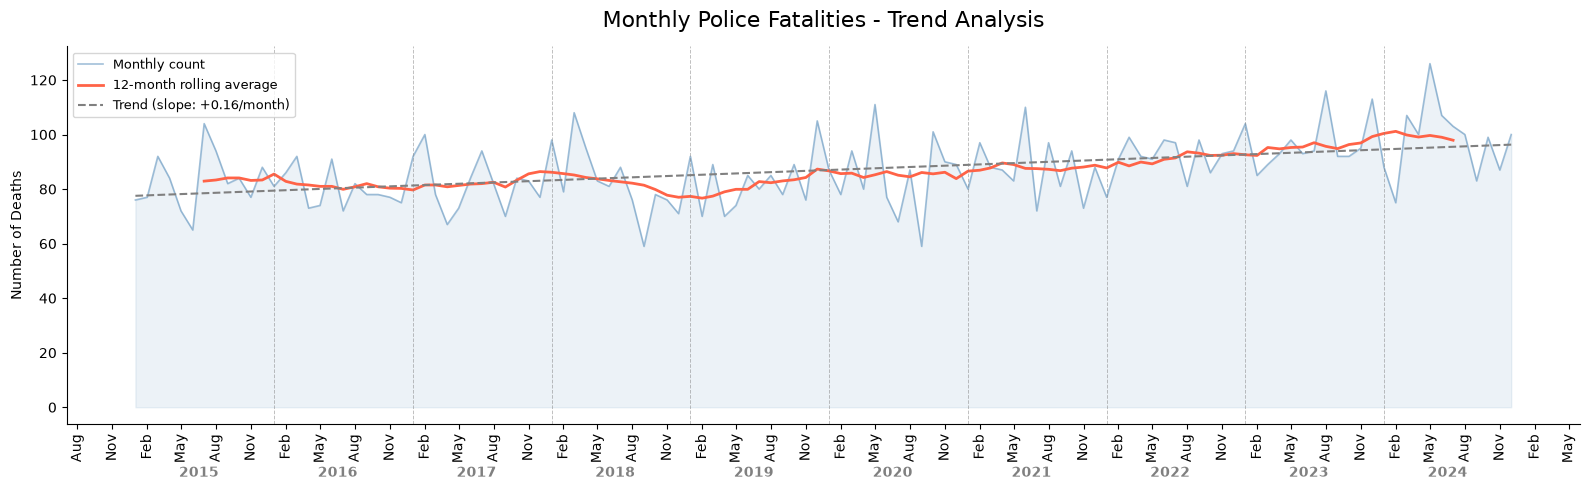

In [52]:
import matplotlib.dates as mdates

df_monthly['x_idx'] = range(len(df_monthly))

z = np.polyfit(df_monthly['x_idx'], df_monthly['count'], 1)
p = np.poly1d(z)
trend = p(df_monthly['x_idx'])

df_monthly['rolling_12'] = df_monthly['count'].rolling(window=12, center=True).mean()

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(
    df_monthly['year_month'],
    df_monthly['count'],
    color='steelblue',
    linewidth=1.2,
    alpha=0.5,
    label='Monthly count'
    )
ax.fill_between(
    df_monthly['year_month'],
    df_monthly['count'],
    alpha=0.1, 
    color='steelblue'
)

ax.plot(
    df_monthly['year_month'], 
    df_monthly['rolling_12'],
    color='tomato',
    linewidth=2,
    label='12-month rolling average'
)

ax.plot(
    df_monthly['year_month'],
    trend,
    color='grey',
    linewidth=1.5,
    linestyle='--',
    label=f'Trend (slope: {z[0]:+.2f}/month)'
    )

ax.set_title(
    'Monthly Police Fatalities - Trend Analysis',
    fontsize=16,
    pad=14
    )
ax.set_xlabel('')
ax.set_ylabel('Number of Deaths')
ax.legend(fontsize=9)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.tick_params(axis='x', rotation=90)
ax.spines[['top', 'right']].set_visible(False)

years = df_monthly['year'].unique()
for year in sorted(years):
    year_start = pd.Timestamp(f'{year}-01-01')
    year_end   = pd.Timestamp(f'{year}-12-01')
    year_mid   = year_start + (year_end - year_start) / 2
    if year != min(years):
        ax.axvline(x=year_start, color='grey', linewidth=0.7,
                   linestyle='--', alpha=0.5)
    ax.annotate(
        str(year),
        xy=(year_mid, 0),
        xycoords=('data', 'axes fraction'),
        xytext=(0, -30),
        textcoords='offset points',
        ha='center', va='top',
        fontsize=10, fontweight='bold', color='grey'
    )

# ── Print trend summary ────────────────────────────────────────────────
print(f"Trend slope : {z[0]:+.3f} deaths/month")
print(f"Overall mean: {df_monthly['count'].mean():.1f} deaths/month")
print(f"Highest month: {df_monthly.loc[df_monthly['count'].idxmax(), 'year_month'].strftime('%b %Y')} "
      f"({df_monthly['count'].max()} deaths)")
print(f"Lowest month : {df_monthly.loc[df_monthly['count'].idxmin(), 'year_month'].strftime('%b %Y')} "
      f"({df_monthly['count'].min()} deaths)")

plt.tight_layout()
plt.show()



## Gender Breakdown of US Police Fatalities

In [53]:
df_gender = df.groupby(['gender']).size().reset_index(name='count')
gender_map = {
    'female': 'Female',
    'male' : 'Male',
    'non-binary' : 'Non-binary'
}
df_gender['gender_name'] = df_gender['gender'].map(gender_map)
df_gender = df_gender.sort_values('count', ascending=False)

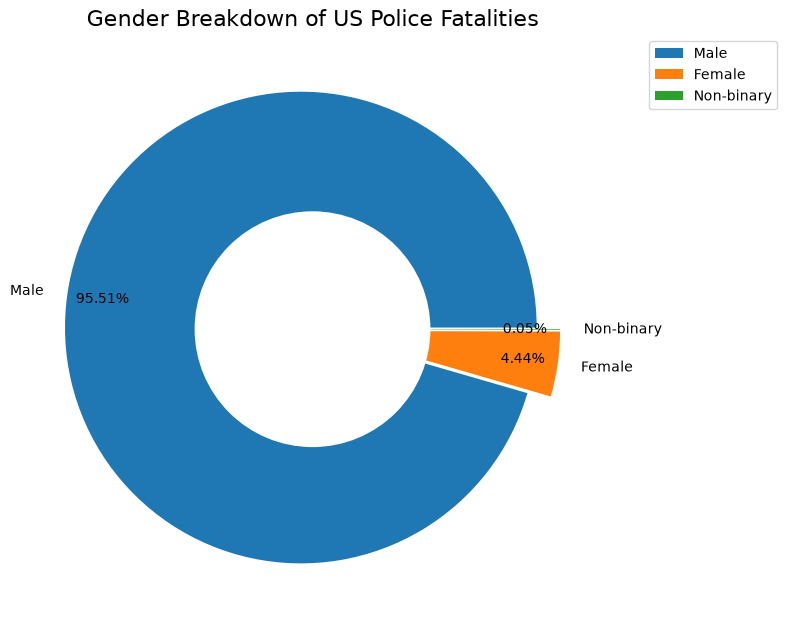

In [54]:
explode = [0.05] * len(df_gender)

fig, ax = plt.subplots(figsize=(8, 8))

ax.pie(
    df_gender['count'],
    labels=df_gender['gender_name'],
    autopct='%1.2f%%',
    pctdistance=0.85,
    explode=explode
)
centre_circle = plt.Circle((0,0), 0.50, fc='white')
ax.add_artist(centre_circle)
ax.set_title(
    "Gender Breakdown of US Police Fatalities",
    fontsize=16,
    fontfamily='DejaVu Sans'
)
plt.legend(
    labels=df_gender['gender_name'],
    loc='upper right',
    bbox_to_anchor=(1.3, 1)
)
plt.tight_layout()
plt.show()


## Age Distribution of Police Fatalities by Gender - case numbers

In [55]:
bins = [0, 18, 25, 35, 45, 55, 65, 100]
age_labels = ['Under 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=age_labels)
df_gender_age = df.groupby(['gender', 'age_group']).size().reset_index(name='count')
df_gender_age['gender_name'] = df_gender_age['gender'].map(gender_map).fillna('Unknown')
# print(df_gender_age)

In [56]:
import plotly.graph_objects as go

male_data = df_gender_age[df_gender_age['gender'] == 'male']
female_data = df_gender_age[df_gender_age['gender'] == 'female']
non_binary_data = df_gender_age[df_gender_age['gender'] == 'non-binary']

fig = go.Figure()

fig.add_trace(go.Bar(
    x=male_data['age_group'].astype(str),
    y=male_data['count'],
    name='Male',
    marker_color='steelblue'
))

fig.add_trace(go.Bar(
    x=female_data['age_group'].astype(str),
    y=female_data['count'],
    name='Female',
    marker_color='tomato'
))

fig.update_layout(
    barmode='group',
    title='Age Distribution of Fatal Police Encounters by Gender (2015–2024)',
    xaxis_title='Age Group',
    yaxis_title='Number of Deaths',
    template='simple_white',
    legend_title='Gender'
)
fig.show()

### Age Distribution by Gender

In [57]:
male = df[df['gender'] == 'male']

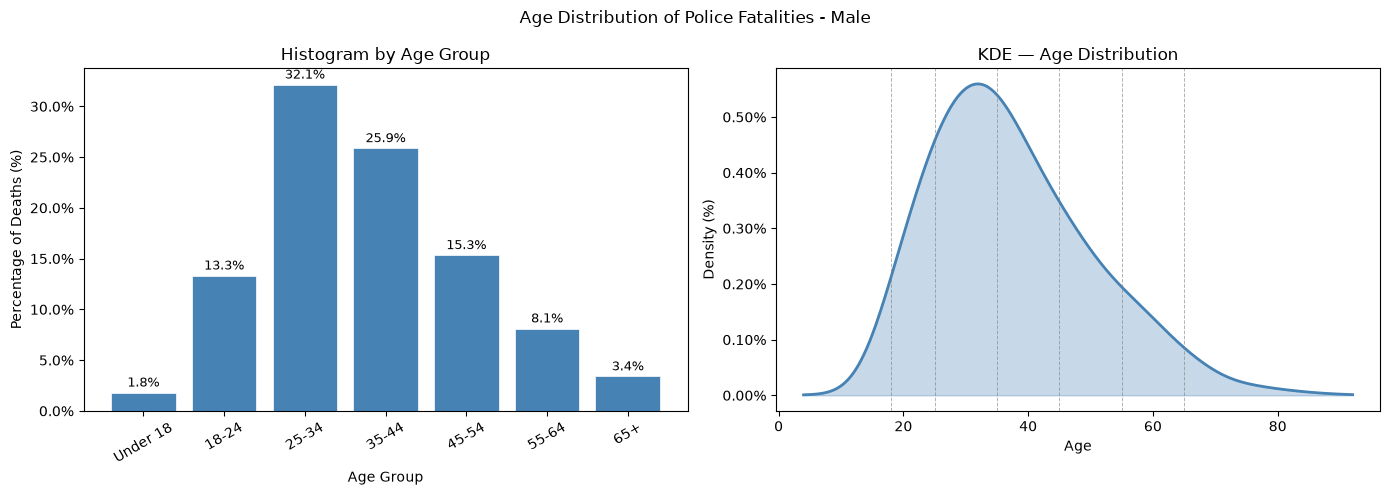

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Age Distribution of Police Fatalities - Male')
# ── Left: Histogram ────────────────────────────────────────────────────
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['Under 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']

ages = male['age'].dropna()
total = len(ages)

counts, edges = np.histogram(ages, bins=bins)
percentages = (counts / total) * 100

bars = axes[0].bar(labels, percentages, color='steelblue', edgecolor='white', linewidth=0.5)

# Add percentage labels on top of each bar
for bar, pct in zip(bars, percentages):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{pct:.1f}%',
        ha='center', va='bottom', fontsize=9
    )

axes[0].set_title('Histogram by Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Percentage of Deaths (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].tick_params(axis='x', rotation=30)

# ── Right: KDE ─────────────────────────────────────────────────────────
kde = gaussian_kde(ages, bw_method=0.3)
x = np.linspace(ages.min(), ages.max(), 500)
y = kde(x)
y_pct = (y / y.sum()) * 100

axes[1].plot(x, y_pct, color='steelblue', linewidth=2)
axes[1].fill_between(x, y_pct, alpha=0.3, color='steelblue')

# Add vertical lines for age group boundaries
for boundary in [18, 25, 35, 45, 55, 65]:
    axes[1].axvline(x=boundary, color='grey', linestyle='--', linewidth=0.7, alpha=0.6)

axes[1].set_title('KDE — Age Distribution')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Density (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

In [59]:
female = df[df['gender'] == 'female']

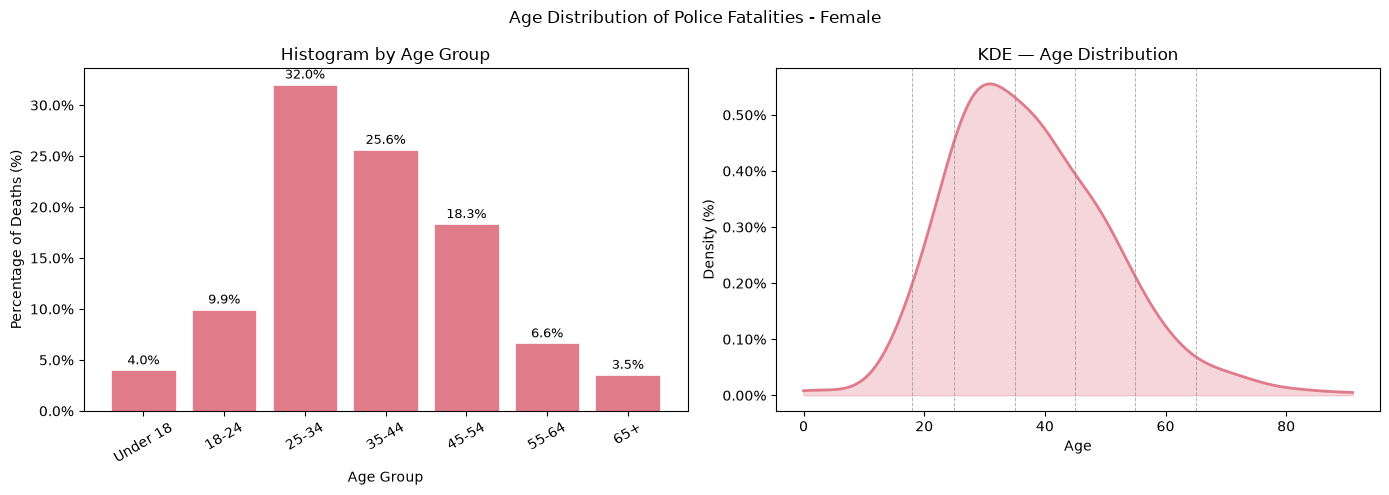

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Age Distribution of Police Fatalities - Female')
# ── Left: Histogram ────────────────────────────────────────────────────
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['Under 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']

ages = female['age'].dropna()
total = len(ages)

counts, edges = np.histogram(ages, bins=bins)
percentages = (counts / total) * 100

bars = axes[0].bar(labels, percentages, color='#E07B8A', edgecolor='white', linewidth=0.5)

# Add percentage labels on top of each bar
for bar, pct in zip(bars, percentages):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{pct:.1f}%',
        ha='center', va='bottom', fontsize=9
    )

axes[0].set_title('Histogram by Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Percentage of Deaths (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].tick_params(axis='x', rotation=30)

# ── Right: KDE ─────────────────────────────────────────────────────────
kde = gaussian_kde(ages, bw_method=0.3)
x = np.linspace(ages.min(), ages.max(), 500)
y = kde(x)
y_pct = (y / y.sum()) * 100

axes[1].plot(x, y_pct, color='#E07B8A', linewidth=2)
axes[1].fill_between(x, y_pct, alpha=0.3, color='#E07B8A')

# Add vertical lines for age group boundaries
for boundary in [18, 25, 35, 45, 55, 65]:
    axes[1].axvline(x=boundary, color='grey', linestyle='--', linewidth=0.7, alpha=0.6)

axes[1].set_title('KDE — Age Distribution')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Density (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

### Racial Breakdown of Police Shooting Fatalities 

In [61]:
df['race'] = df['race'].apply(lambda x: 'Mixed' if ',' in str(x) else x)
races = df.groupby(['race']).size().reset_index(name='count').sort_values('count', ascending=False)

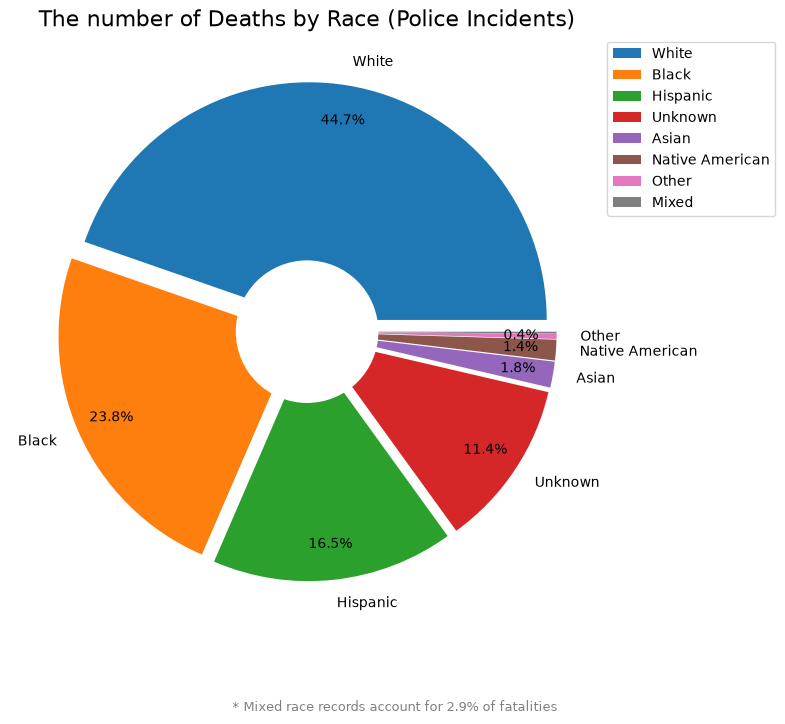

In [62]:
explode = [0.05] * len(races)

fig, ax = plt.subplots(figsize=(8, 8))

labels = [r if c/total > 0.04 else '' for r, c in zip(races['race'], races['count'])]
mixed_pct = races[races['race'] == 'Mixed']['count'].sum() / total * 100

def autopct_filter(pct):
    return f'{pct:.1f}%' if pct > 0.3 else ''

ax.pie(
    races['count'],
    labels=labels,
    autopct=autopct_filter,
    pctdistance=0.85,
    explode=explode
)
centre_circle = plt.Circle((0,0), 0.30, fc='white')
ax.add_artist(centre_circle)
ax.set_title(
    'The number of Deaths by Race (Police Incidents)',
    fontsize=16,
    fontfamily='DejaVu Sans'
)
fig.text(0.5, 0.01, f'* Mixed race records account for {mixed_pct:.1f}% of fatalities',
         ha='center', fontsize=9, color='grey')
plt.legend(
    labels=races['race'],
    loc='upper right',
    bbox_to_anchor=(1.3, 1)
)
plt.tight_layout()
plt.show()

### Number of Death by Race and Months

In [63]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df_monthly_races = df.groupby(['year', 'month', 'race']). size(). reset_index(name='count')
df_monthly_races['year_month'] = pd.to_datetime(df_monthly_races[['year', 'month']].assign(day=1))
# df_monthly_races[df_monthly_races['race'] == 'White']

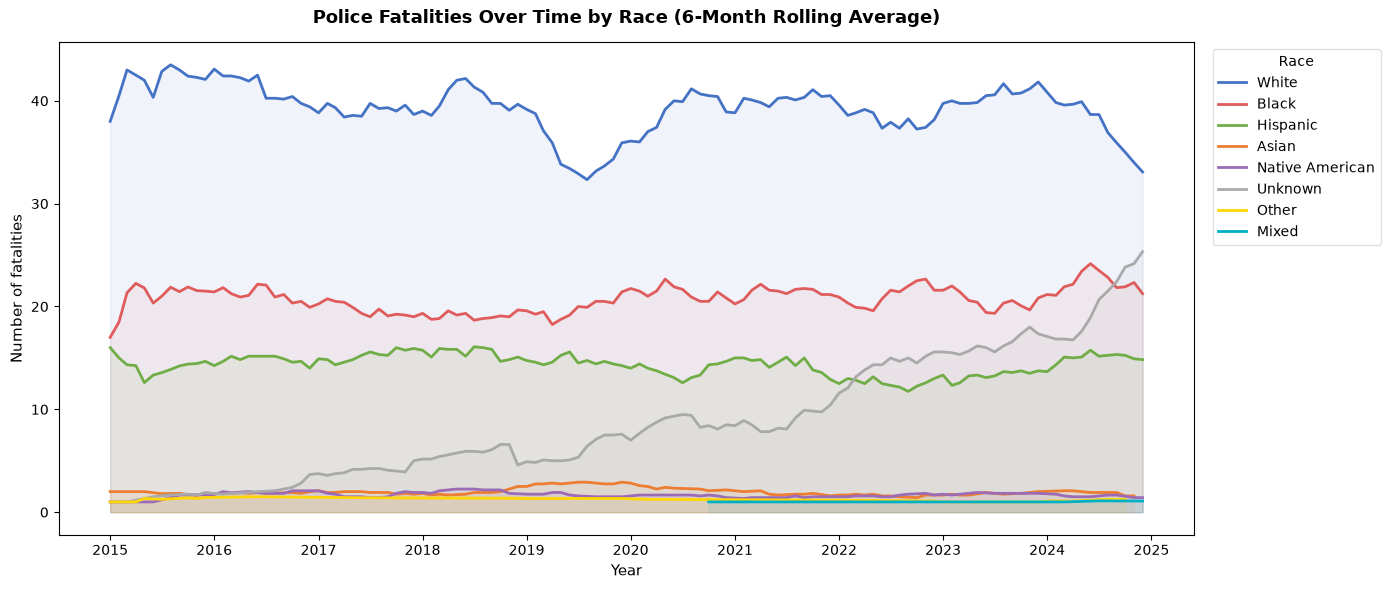

In [64]:
races_to_plot = ['White', 'Black', 'Hispanic', 'Asian', 'Native American', 'Unknown', 'Other', 'Mixed']
colors = ['#4472C4', '#E05C5C', '#70AD47', '#ED7D31', '#9B6BB5', '#A9A9A9', '#FFD700', '#00B0C8']

fig, ax = plt.subplots(figsize=(14, 6))

for race, color in zip(races_to_plot, colors):
    subset = df_monthly_races[df_monthly_races['race'] == race].copy()
    if len(subset) < 10:
        continue
    subset = subset.sort_values('year_month')
    subset['rolling'] = subset['count'].rolling(12, min_periods=1).mean()  # 6-month rolling average
    ax.plot(subset['year_month'], subset['rolling'], color=color, linewidth=2, label=race)
    ax.fill_between(subset['year_month'], subset['rolling'], alpha=0.08, color=color)

ax.set_title('Police Fatalities Over Time by Race (6-Month Rolling Average)', fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Number of fatalities', fontsize=11)
ax.legend(title='Race', framealpha=0.6, bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

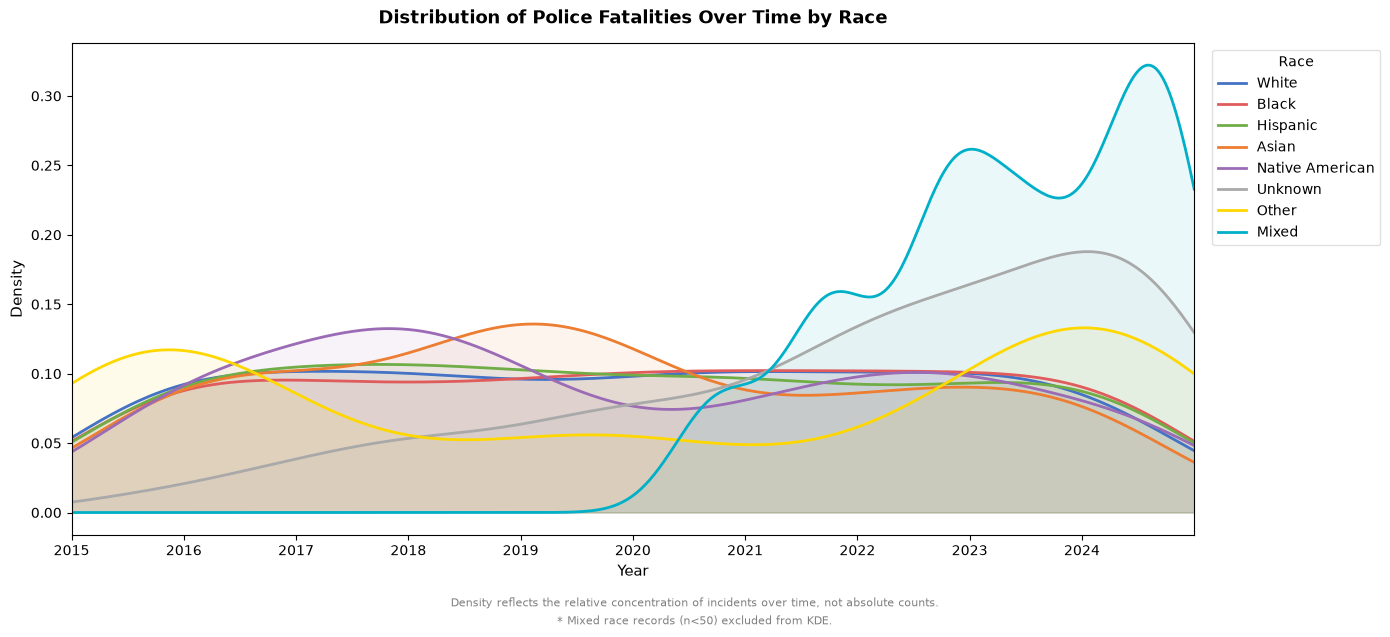

In [65]:
races_to_plot = ['White', 'Black', 'Hispanic', 'Asian', 'Native American', 'Unknown', 'Other', 'Mixed']
colors = ['#4472C4', '#E05C5C', '#70AD47', '#ED7D31', '#9B6BB5', '#A9A9A9', '#FFD700', '#00B0C8']

fig, ax = plt.subplots(figsize=(14, 6))

x = np.linspace(2015, 2025, 500)

for race, color in zip(races_to_plot, colors):
    values = df[df['race'] == race]['date'].dt.year + (df[df['race'] == race]['date'].dt.dayofyear / 365)
    if len(values) < 10:
        continue
    kde = gaussian_kde(values, bw_method=0.3)
    ax.plot(x, kde(x), color=color, linewidth=2, label=race)
    ax.fill_between(x, kde(x), alpha=0.08, color=color)

ax.set_title('Distribution of Police Fatalities Over Time by Race', fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_xlim(2015, 2025)
ax.set_xticks(range(2015, 2025))
ax.legend(title='Race', framealpha=0.6, bbox_to_anchor=(1.01, 1), loc='upper left')

fig.text(0.5, -0.02,
         'Density reflects the relative concentration of incidents over time, not absolute counts.',
         ha='center', fontsize=8, color='grey')
fig.text(0.5, -0.05,
         '* Mixed race records (n<50) excluded from KDE.',
         ha='center', fontsize=8, color='grey')

plt.tight_layout()
plt.show()

### Which state has more risks of facing police shooting incidents?

In [66]:
import plotly.express as px

# Group by state for choropleths
incidents_by_state = df.groupby('state').size().reset_index(name='count').sort_values('count', ascending=False)

fig = px.choropleth(
    incidents_by_state,
    locations='state',
    locationmode='USA-states',
    color='count',
    scope='usa',
    color_continuous_scale='RdYlGn_r',
    title='Fatal Police Shootings by State',
)

fig.update_layout(
    geo=dict(showlakes=True, lakecolor='LightBlue'),
    title_x=0.5
)

fig.show()

In [67]:
# --- Population by state (2020 Census estimates, millions) ---
# If you already have a population lookup elsewhere in the project, use that instead.
state_pop = pd.read_csv(
    "https://raw.githubusercontent.com/jakevdp/data-USstates/master/state-population.csv"
)
state_pop = state_pop[state_pop["ages"] == "total"]
state_pop = state_pop[state_pop["year"] == state_pop["year"].max()]

# state abbreviation -> full name mapping needed for merge if your incidents df uses abbreviations
state_pop = state_pop.rename(columns={"state/region": "state_abbr", "population": "pop"})

# --- Incidents count per state ---
incidents_by_state = (
    df.groupby("state")
    .size()
    .reset_index(name="incident_count")
)

# Merge and compute rate per million
merged = incidents_by_state.merge(
    state_pop[["state_abbr", "pop"]],
    left_on="state",
    right_on="state_abbr",
    how="left"
)
merged["rate_per_million"] = merged["incident_count"] / (merged["pop"] / 1_000_000)

fig_map = px.choropleth(
    merged,
    locations="state",          # must be 2-letter state codes
    locationmode="USA-states",
    color="rate_per_million",
    scope="usa",
    color_continuous_scale="Reds",
    labels={"rate_per_million": "Incidents per million"},
    title="Police Shooting Incidents per Million Residents by State"
)
fig_map.update_layout(geo=dict(bgcolor="rgba(0,0,0,0)"))
fig_map.show()

### The relations between police shooting incidents and race

In [68]:
import os
import requests
import pandas as pd
from dotenv import load_dotenv

load_dotenv('data.env')
API_KEY = os.getenv("US_CENSUS_KEY", "").strip()
if not API_KEY:
    raise ValueError("US_CENSUS_KEY not found — check your .env file")

variables = {
    "B02001_001E": "total",
    "B02001_002E": "white",
    "B02001_003E": "black",
    "B02001_004E": "native_american",
    "B02001_005E": "asian",
    "B02001_006E": "pacific_islander",
    "B02001_007E": "other",
    "B02001_008E": "mixed",
}

url = (
    f"https://api.census.gov/data/2022/acs/acs5"
    f"?get=NAME,{','.join(variables.keys())}"
    f"&for=state:*&key={API_KEY}"
)

resp = requests.get(url)
data = resp.json()
census_df = pd.DataFrame(data[1:], columns=data[0])
census_df = census_df.rename(columns=variables)

for col in variables.values():
    census_df[col] = pd.to_numeric(census_df[col])

state_race_pop = census_df.melt(
    id_vars=["NAME"],
    value_vars=list(variables.values())[1:],
    var_name="race",
    value_name="population"
).rename(columns={"NAME": "state"})

# --- Add Hispanic (ethnicity, not part of B02001) from table B03002 ---
url_hispanic = (
    f"https://api.census.gov/data/2022/acs/acs5"
    f"?get=NAME,B03002_012E"
    f"&for=state:*&key={API_KEY}"
)

resp_hispanic = requests.get(url_hispanic)
data_hispanic = resp_hispanic.json()

hispanic_df = pd.DataFrame(data_hispanic[1:], columns=data_hispanic[0])

# Drop the FIPS 'state' column the API auto-appends, then rename NAME -> state
hispanic_df = hispanic_df.drop(columns=["state"])
hispanic_df = hispanic_df.rename(columns={"NAME": "state", "B03002_012E": "population"})

hispanic_df["population"] = pd.to_numeric(hispanic_df["population"])
hispanic_df["race"] = "hispanic"
hispanic_df = hispanic_df[["state", "race", "population"]]

state_race_pop = pd.concat([state_race_pop, hispanic_df], ignore_index=True)

# --- Fold pacific_islander into other ---
mask = state_race_pop["race"] == "pacific_islander"
state_race_pop.loc[mask, "race"] = "other"

state_race_pop["race"] = state_race_pop["race"].replace("two_or_more", "mixed")

state_race_pop = (
    state_race_pop
    .groupby(["state", "race"], as_index=False)["population"]
    .sum()
)

# print(state_race_pop["race"].unique())
# state_race_pop.head()

In [69]:
state_race_pop['race'].unique()

<StringArray>
['asian', 'black', 'hispanic', 'mixed', 'native_american', 'other', 'white']
Length: 7, dtype: str

In [70]:
state_abbreviations = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas',
    'CA': 'California', 'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware',
    'FL': 'Florida', 'GA': 'Georgia', 'HI': 'Hawaii', 'ID': 'Idaho',
    'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa', 'KS': 'Kansas',
    'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland',
    'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi',
    'MO': 'Missouri', 'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada',
    'NH': 'New Hampshire', 'NJ': 'New Jersey', 'NM': 'New Mexico', 'NY': 'New York',
    'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio', 'OK': 'Oklahoma',
    'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island', 'SC': 'South Carolina',
    'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah',
    'VT': 'Vermont', 'VA': 'Virginia', 'WA': 'Washington', 'WV': 'West Virginia',
    'WI': 'Wisconsin', 'WY': 'Wyoming', 'DC': 'District of Columbia'
}
df["state_full"] = df["state"].map(state_abbreviations)

In [84]:
# df['race'].unique()

In [85]:
# 1. Map race values first
race_mapping = {
    "White": "white",
    "Black": "black",
    "Asian": "asian",
    "Native American": "native_american",
    "Mixed": "mixed",
    "Other": "other",
    "Hispanic": "hispanic",
    "Unknown": "unknown",
}
df["race_full"] = df["race"].map(race_mapping)

# remove Unknown as US census doens't include such group
df = df[df["race_full"] != "unknown"]

# 2. Rebuild incidents_by_state_race from the now-mapped df
incidents_by_state_race = (
    df.groupby(["state", "state_full", "race", "race_full"])
    .size()
    .reset_index(name="incident_count")
)

# print(incidents_by_state_race)

# 3. Rebuild merged_sr
merged_sr = incidents_by_state_race.merge(
    state_race_pop.rename(columns={"state": "state_full", "race": "race_full"}),
    on=["state_full", "race_full"],
    how="left"
)
merged_sr["rate_per_million"] = merged_sr["incident_count"] / (merged_sr["population"] / 1_000_000)

# Sanity check before plotting
# print(merged_sr["rate_per_million"].isna().sum())
# merged_sr[merged_sr["rate_per_million"].isna()]

In [ ]:
merged_sr.head()

<bound method NDFrame.head of     state     state_full             race        race_full  incident_count  \
0      AK         Alaska            Asian            asian               3   
1      AK         Alaska            Black            black               4   
2      AK         Alaska  Native American  native_american              13   
3      AK         Alaska            Other            other               1   
4      AK         Alaska            White            white              35   
..    ...            ...              ...              ...             ...   
222    WV  West Virginia            White            white              67   
223    WY        Wyoming            Black            black               2   
224    WY        Wyoming         Hispanic         hispanic               2   
225    WY        Wyoming  Native American  native_american               3   
226    WY        Wyoming            White            white              25   

     population  rate_per_million

In [117]:
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# ---  Build minority % by state from state_race_pop ---
pivot = state_race_pop.pivot_table(
    index="state", columns="race", values="population", aggfunc="sum"
).fillna(0)

# total population = white + all minority races (avoid double-counting hispanic,
# which overlaps with race categories in Census methodology — treat as its own
# bucket only if you want ethnicity folded in; here we use race total as denominator)
race_cols = [c for c in pivot.columns if c != "hispanic"]
pivot["total"] = pivot[race_cols].sum(axis=1)
pivot["minority"] = pivot["total"] - pivot["white"]
pivot["minority_pct"] = (pivot["minority"] / pivot["total"]) * 100

# print(pivot.shape)
# print(pivot.head())
# print(pivot.dtypes)

# ---  Map full state names -> two-letter abbreviations for plotly ---
full_to_abbrev = {v: k for k, v in state_abbreviations.items()}
minority_df = pivot.reset_index()[["state", "minority_pct"]].rename(
    columns={"state": "state_full"}
)
minority_df["state"] = minority_df["state_full"].map(full_to_abbrev)

state_overall_rate = (
    merged_sr.groupby("state", as_index=False)
    .agg(total_incidents=("incident_count", "sum"), total_population=("population", "sum"))
)
state_overall_rate["rate_per_million"] = (
    state_overall_rate["total_incidents"] / state_overall_rate["total_population"] * 1_000_000
)
# --- Side-by-side comparison with incident rate map ---
compare_df = minority_df.merge(
    state_overall_rate[["state", "rate_per_million"]], on="state", how="left"
)

fig_compare = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "choropleth"}, {"type": "choropleth"}]],
    subplot_titles=("% Minority Population", "Incidents per 1,000,000"),
)

fig_compare.add_trace(
    go.Choropleth(
        locations=compare_df["state"],
        z=compare_df["minority_pct"],
        locationmode="USA-states",
        colorscale="Reds",
        colorbar=dict(title="% Minority", x=0.44),
    ),
    row=1, col=1,
)

fig_compare.add_trace(
    go.Choropleth(
        locations=compare_df["state"],
        z=compare_df["rate_per_million"],
        locationmode="USA-states",
        colorscale="Blues",
        zmin=0,
        zmax=100,
        colorbar=dict(title="Rate / Million", x=1.0),
    ),
    row=1, col=2,
)

fig_compare.update_geos(scope="usa")
fig_compare.update_layout(
    height=500,
    title=(
        "Minority Population Share vs. Police Incident Rate by State"
        "<br>"
        "<sup><i>Left: % non-white population (2022 ACS). Right: incidents per 1,000,000 residents</i></sup>"
    ),
)
fig_compare.show()

In [74]:
top_states = df["state"].value_counts().head(12).index.tolist()

state_rank = {state: i + 1 for i, state in enumerate(top_states)}

plot_df = merged_sr[merged_sr["state"].isin(top_states)].copy()
plot_df["rank"] = plot_df["state"].map(state_rank)
plot_df["facet_label"] = "#" + plot_df["rank"].astype(str) + " " + plot_df["state_full"]

plot_df = plot_df.sort_values("rank")
facet_order = plot_df.drop_duplicates("facet_label")["facet_label"].tolist()

fig_facets = px.bar(
    plot_df,
    x="race_full",
    y="rate_per_million",
    facet_col="facet_label",
    facet_col_wrap=4,
    color="race",
    category_orders={"facet_label": facet_order},
    title=(
        "Incidents per Million by Race, Top 12 States"
        "<br>"
        "<sup><i>Rate shown as incidents per million people</i></sup>"
    ),
    labels={"race_full": "Race"}
)

# Hide x-axis entirely (categories now only shown via legend)
fig_facets.update_xaxes(visible=False)

# Remove y-axis title from every facet (was "rate_per_million")
fig_facets.for_each_yaxis(lambda axis: axis.update(title=""))

fig_facets.update_layout(
    height=700,
    legend=dict(
        title="Race",
        orientation="v",
        yanchor="middle",
        y=0.5,
        xanchor="left",
        x=1.02
    )
)

fig_facets.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))

fig_facets.show()

### Police Shooting Fatalities Across US Cities

In [75]:
incidents_by_city = df.groupby(['city', 'state']).size().reset_index(name='count').sort_values('count', ascending=True)

geo = pd.read_csv('https://raw.githubusercontent.com/kelvins/US-Cities-Database/main/csv/us_cities.csv')
# has CITY, STATE_CODE, LATITUDE, LONGITUDE columns

incidents_by_city = incidents_by_city.merge(
    geo[['CITY', 'STATE_CODE', 'LATITUDE', 'LONGITUDE']],
    left_on=['city', 'state'],
    right_on=['CITY', 'STATE_CODE'],
    how='left'
).rename(columns={'LATITUDE': 'lat', 'LONGITUDE': 'lon'})

In [76]:
import plotly.express as px

fig = px.scatter_mapbox(
    incidents_by_city,
    lat='lat',
    lon='lon',
    size='count',
    hover_name='city',
    hover_data={'count': True, 'lat': False, 'lon': False},
    color='count',
    color_continuous_scale='Reds',
    size_max=30,
    zoom=3,
    mapbox_style='carto-positron',
    title='Where Police Killings Happen: Incidents by City'
)
fig.show()

/tmp/ipykernel_5944/2831746927.py:3: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


### Gun Ownership Rates by State

In [77]:
# Read
df_gun_ownership = pd.read_excel(
    "TL-354-State-Level Estimates of Household Firearm Ownership.xlsx", 
    sheet_name="State-Level Data & Factor Score"
    ) 

gun_ownership_2016 = df_gun_ownership[df_gun_ownership["Year"] == 2016][["STATE", "HFR"]].reset_index(drop=True)
# gun_ownership_2016

In [78]:
gun_ownership_2016["HFR_pct"] = gun_ownership_2016["HFR"] * 100

# Reverse the existing abbreviation dict: full name -> abbreviation
name_to_abbr = {v: k for k, v in state_abbreviations.items()}

gun_ownership_2016["state_abbr"] = gun_ownership_2016["STATE"].map(name_to_abbr)

# Sanity check — confirm every state matched
print(gun_ownership_2016["state_abbr"].isna().sum())
gun_ownership_2016[gun_ownership_2016["state_abbr"].isna()]

fig_gun_map = px.choropleth(
    gun_ownership_2016,
    locations="state_abbr",
    locationmode="USA-states",
    color="HFR_pct",
    scope="usa",
    color_continuous_scale="Blues",
    labels={"HFR_pct": "Household Firearm Ownership (%)"},
    title=(
        "Household Firearm Ownership Rate by State (2016)"
        "<br>"
        "<sup><i>Source: RAND Corporation, State-Level Estimates of Household Firearm Ownership</i></sup>"
    )
)
fig_gun_map.update_traces(
    hovertemplate="%{location}<br>HFR: %{z:.1f}%<extra></extra>"
)
fig_gun_map.update_coloraxes(colorbar_ticksuffix="%")
fig_gun_map.update_layout(geo=dict(bgcolor="rgba(0,0,0,0)"))
fig_gun_map.show()

0


### Annual Police Shooting Incidents by Threat Level

In [79]:
def classify_armed(value):
    if pd.isna(value):
        return "Unknown"
    if value in ["undetermined", "unknown"]:
        return "Unknown"
    if value == "unarmed":
        return "Unarmed"
    # Anything else (gun, knife, replica, blunt_object, vehicle, other,
    # or any comma-separated combination of these) counts as armed
    return "Armed"

df["armed_status"] = df["armed"].apply(classify_armed)

In [80]:
# Per-state armed/unarmed counts (long format for px.pie facets)
state_armed_long = (
    df[df["armed_status"] != "Unknown"]
    .groupby(["state", "armed_status"])
    .size()
    .reset_index(name="count")
)

# Merge with gun ownership rate to get sort order + full state names
state_armed_long = state_armed_long.merge(
    gun_ownership_2016[["state_abbr", "STATE", "HFR_pct"]],
    left_on="state",
    right_on="state_abbr",
    how="inner"
)

# Sort states by gun ownership rate, build rank-labeled facet column
state_order = (
    state_armed_long[["state", "STATE", "HFR_pct"]]
    .drop_duplicates()
    .sort_values("HFR_pct", ascending=False)
    .reset_index(drop=True)
)
state_order["rank"] = state_order.index + 1
state_order["facet_label"] = (
    "#" + state_order["rank"].astype(str) + " " + state_order["STATE"] +
    "<br> " + state_order["HFR_pct"].round(1).astype(str) + "%"
)

state_armed_long = state_armed_long.merge(
    state_order[["state", "facet_label"]], on="state"
)

facet_order = state_order["facet_label"].tolist()

fig_pies = px.pie(
    state_armed_long,
    names="armed_status",
    values="count",
    facet_col="facet_label",
    facet_col_wrap=6,
    facet_row_spacing=0.03,
    facet_col_spacing=0.05,
    color="armed_status",
    color_discrete_map={"Armed": "#d62728", "Unarmed": "#1f77b4"},
    category_orders={"facet_label": facet_order},
    title=(
        "Armed vs. Unarmed Incidents by State, Sorted by Gun Ownership Rate"
        "<br>"
        "<sup><i>States ranked highest to lowest gun ownership (RAND, 2016)</i></sup>"
    )
)
fig_pies.update_traces(textposition="inside", textinfo="percent")
fig_pies.update_layout(height=1400)  # tall, since 50+ pies need vertical room
fig_pies.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1], font_size=10))
fig_pies.show()

### Are There Any Relationships Between Household Gun Ownership and Police Incidents?

In [81]:
# % of incidents per state where suspect was classified as Armed
state_armed_pct = (
    df[df["armed_status"] != "Unknown"]
    .groupby("state")["armed_status"]
    .apply(lambda x: (x == "Armed").mean() * 100)
    .reset_index(name="pct_armed")
)

# Merge with gun ownership data
correlation_df = state_armed_pct.merge(
    gun_ownership_2016[["state_abbr", "STATE", "HFR_pct"]],
    left_on="state",
    right_on="state_abbr",
    how="inner"
).rename(columns={"STATE": "state_full"})

# print(correlation_df.shape)
# correlation_df.head()

In [82]:
correlation_df["ownership_rank"] = correlation_df["HFR_pct"].rank(ascending=False)
correlation_df["armed_rank"] = correlation_df["pct_armed"].rank(ascending=False)
correlation_df["combined_rank"] = correlation_df["ownership_rank"] + correlation_df["armed_rank"]

print(correlation_df.columns.tolist())  # confirm combined_rank is now present

['state', 'pct_armed', 'state_abbr', 'state_full', 'HFR_pct', 'ownership_rank', 'armed_rank', 'combined_rank']


In [83]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go


# Build the ranking list
top_10_aligned = correlation_df.nsmallest(10, "combined_rank")[
    ["state_full", "HFR_pct", "pct_armed"]
].reset_index(drop=True)
top_10_aligned.insert(0, "Rank", range(1, 11))

fig = make_subplots(
    rows=1, cols=2,
    column_widths=[0.7, 0.3],
    specs=[[{"type": "scatter"}, {"type": "table"}]],
    subplot_titles=("", "Top 10 Aligned States")
)

# --- Scatter chart ---
scatter = px.scatter(
    correlation_df,
    x="HFR_pct",
    y="pct_armed",
    hover_name="state_full",
    trendline="ols",
    labels={"HFR_pct": "Household Gun Ownership Rate (%)", "pct_armed": "% of Incidents Classified as Armed"}
)
for trace in scatter.data:
    fig.add_trace(trace, row=1, col=1)

# --- Ranking table ---
fig.add_trace(
    go.Table(
        header=dict(values=["#", "State", "Ownership %", "Armed %"], fill_color="lightgrey", align="left"),
        cells=dict(
            values=[
                top_10_aligned["Rank"],
                top_10_aligned["state_full"],
                top_10_aligned["HFR_pct"].round(1),
                top_10_aligned["pct_armed"].round(1),
            ],
            align="left"
        )
    ),
    row=1, col=2
)

fig.update_layout(
    title=(
        "Gun Ownership Rate vs. % of Incidents Classified as Armed, by State"
        "<br>"
        "<sup><i>Gun ownership: RAND 2016 estimate. Incidents: WaPo Fatal Force, 2015–2026</i></sup>"
    ),
    height=600,
    width=1100,
    showlegend=False
)
fig.update_xaxes(title_text="Household Gun Ownership Rate (%)", row=1, col=1)
fig.update_yaxes(title_text="% of Incidents Classified as Armed", row=1, col=1)

fig.show()